In [53]:
import numpy as np
from sim_library.constants import pi, hbar, k_eff, m, omega_eg, dR
from sim_library.simulation import simulate_pulses_single_atom
from sim_library.sequences import swap23_gate, exchange10_gate, RR3short_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq
import matplotlib.pyplot as plt

In [51]:
### modified ex10 gate
rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

detuning  = omega_eg/2
free_time = 2*pi/detuning

time_steps = 1

interf_cooler = PulseSequence()

pulse_1 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi/2
pulse_2 = UpPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi/2
pulse_3 = DownPulse(laser_det=np.full(time_steps, dR), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) #down pi/2 pulse, phase = pi/2


MDFE_1 = gen_MDFEup_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=time_steps) 
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, +detuning)), duration=7*free_time/8) 

interf_cooler.add_pulses([pulse_1,
                          
                        # freevolve_1,
                        MDFE_1,
                        # pulse_2,
                          # pulse_3,
                         pulse_1,
                ])



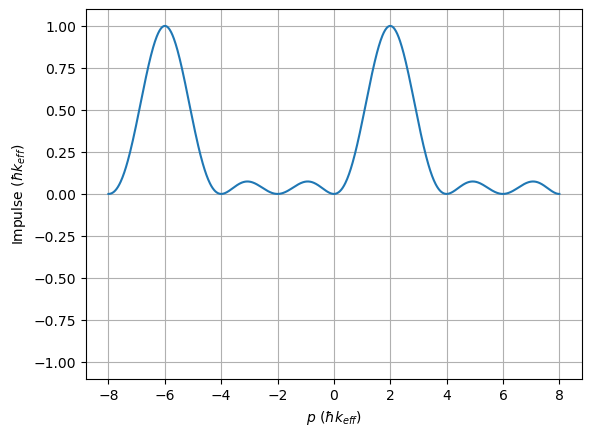

In [54]:
rabi_freq = 2*pi*1e9
rabi_time = 2*pi/rabi_freq

# omega_time = 2*pi/omega_eg #chosen to be much larger than recoil shift

time_steps = 1

RR3 = RR3short_gate(rabi_freq=rabi_freq, time_steps=time_steps)

exgate = exchange10_gate(rabi_freq=rabi_freq, time_steps=time_steps)

swap = swap23_gate(rabi_freq=rabi_freq, time_steps=time_steps)

p_min = -16
p_max = 16
basis = np.arange(p_min, p_max + 1)

initial_state = np.zeros(shape=len(basis), dtype=np.complex128)

initial_state[16] = 1

initial_state = initial_state/ np.linalg.norm(initial_state)

p_vals = np.linspace(-8, 8, 1000)*hbar*k_eff
doppler_shifts = p_vals*k_eff/m

impulses = np.zeros(len(p_vals))

for i in range(len(p_vals)):

    wave_func, times = simulate_pulses_single_atom(pulse_seq= swap, basis= basis, initial_state=initial_state, d_shift=doppler_shifts[i])

    final = wave_func[-1,:]
    final = final/np.linalg.norm(final)
    probs = np.abs(final)**2

    avg_impulse = np.average(basis, weights=probs)

    impulses[i] = avg_impulse




plt.plot(p_vals/(hbar*k_eff), impulses)
plt.xlabel(r'$p$ ($\hbar k_{eff}$)')
plt.ylabel(r'Impulse ($\hbar k_{eff}$)')
plt.ylim(-1.1,1.1)
plt.grid()
plt.show()



  


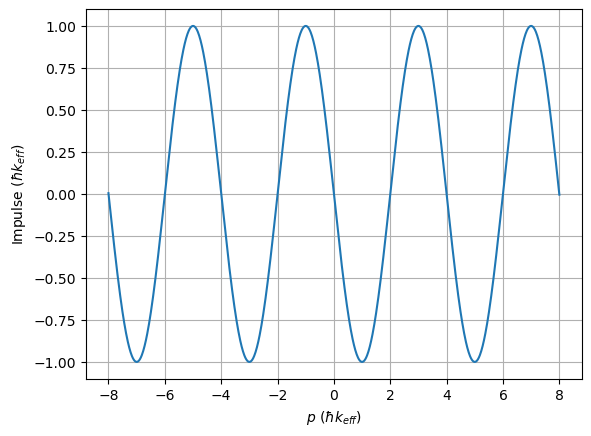

In [159]:
flipped_impulses = -1*np.flip(impulses)

new_impulses = flipped_impulses + impulses
plt.plot(p_vals/(hbar*k_eff), new_impulses)
plt.xlabel(r'$p$ ($\hbar k_{eff}$)')
plt.ylabel(r'Impulse ($\hbar k_{eff}$)')
plt.ylim(-1.1,1.1)
plt.grid()
plt.show()


In [52]:
x = np.array([0,1,2,3,4])
print(x)
print(np.flip(x))

[0 1 2 3 4]
[4 3 2 1 0]
